# 🧠 MRI Brain Tumor MLOps Pipeline
> ResNet50 Classifier + ResUNet Segmentation | Kaggle Data | MLflow Tracking

**Runtime → Change runtime type → T4 GPU** before running!

## ✅ Step 1 — Check GPU

In [52]:
import tensorflow as tf
print('TensorFlow:', tf.__version__)
print('GPU Available:', tf.config.list_physical_devices('GPU'))
!nvidia-smi

TensorFlow: 2.20.0
GPU Available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Sun May  3 23:01:28 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   62C    P0             29W /   70W |    4219MiB /  15360MiB |      0%      Default |
|                                      

## ✅ Step 2 — Mount Google Drive

In [53]:
# Install colabcode for VS Code connection
!pip install colabcode -q

In [87]:
from google.colab import drive
import zipfile, shutil, os
drive.mount('/content/drive')

import os
PROJECT_DIR = '/content/drive/MyDrive/mri-brain-tumor-mlops'
os.makedirs(PROJECT_DIR, exist_ok=True)
os.chdir(PROJECT_DIR)
print(f'Working directory: {os.getcwd()}')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Working directory: /content/drive/MyDrive/mri-brain-tumor-mlops


## ✅ Step 3 — Upload & Unzip Project Files

In [88]:
# Upload or extract your mri-brain-tumor-mlops.zip here
import zipfile
from pathlib import Path

zip_path = Path('/content/drive/MyDrive/mri-brain-tumor-mlops.zip')
if zip_path.exists():
    print(f'Found zip in Drive: {zip_path}')
    with zipfile.ZipFile(zip_path, 'r') as z:
        z.extractall('/content/drive/MyDrive/')
    print(f'Extracted: {zip_path}')
else:
    from google.colab import files
    print('Upload your mri-brain-tumor-mlops.zip now:')
    uploaded = files.upload()  # select mri-brain-tumor-mlops.zip
    for fname in uploaded:
        with zipfile.ZipFile(fname, 'r') as z:
            z.extractall('/content/drive/MyDrive/')
        print(f'Extracted: {fname}')

os.chdir(PROJECT_DIR)
!ls -la

Found zip in Drive: /content/drive/MyDrive/mri-brain-tumor-mlops.zip
Extracted: /content/drive/MyDrive/mri-brain-tumor-mlops.zip
total 812
drwx------ 2 root root   4096 May  4 01:08 configs
drwx------ 4 root root   4096 May  3 22:25 data
-rw------- 1 root root    837 May  4 01:08 docker-compose.yml
-rw------- 1 root root    342 May  4 01:08 Dockerfile
drwx------ 3 root root   4096 May  3 22:18 .github
drwx------ 2 root root   4096 May  3 22:37 logs
-rw------- 1 root root    969 May  4 01:08 Makefile
drwx------ 4 root root   4096 May  4 00:49 mlflow_artifacts
-rw------- 1 root root 761856 May  4 00:50 mlflow.db
drwx------ 2 root root   4096 May  4 00:47 models
-rw------- 1 root root  22837 May  4 01:08 MRI_BrainTumor_MLOps_Colab.ipynb
drwx------ 2 root root   4096 May  4 01:08 pipelines
-rw------- 1 root root   2337 May  4 01:08 README.md
drwx------ 2 root root   4096 May  4 00:59 reports
-rw------- 1 root root    325 May  4 01:08 requirements.txt
drwx------ 9 root root   4096 May  4 01

## ✅ Step 4 — Install Dependencies

In [56]:
%%capture
!pip install mlflow evidently gradio fastapi uvicorn pyyaml opencv-python-headless kaggle
print('✅ All packages installed')

## ✅ Step 5 — Download Kaggle Dataset (LGG MRI)

In [57]:
# ----------------------------------------------------------
# Option A: Use kaggle.json from Google Drive
# ----------------------------------------------------------
import os
import shutil
from pathlib import Path

kaggle_dir = os.path.expanduser('~/.kaggle')
os.makedirs(kaggle_dir, exist_ok=True)
kaggle_path = os.path.join(kaggle_dir, 'kaggle.json')
drive_kaggle = Path('/content/drive/MyDrive/kaggle.json')

def install_kaggle_json(src_path):
    shutil.copy(str(src_path), kaggle_path)
    os.chmod(kaggle_path, 0o600)
    print(f'✅ kaggle.json copied to {kaggle_path}')

if os.path.exists(kaggle_path):
    print(f'✅ kaggle.json already exists at {kaggle_path}')
elif drive_kaggle.exists():
    install_kaggle_json(drive_kaggle)
else:
    print('kaggle.json not found in Drive at /content/drive/MyDrive/kaggle.json.')
    print('Please upload kaggle.json to your Google Drive and rerun this cell.')
    print('Or use the Colab file upload UI to place kaggle.json into Drive first.')
    raise FileNotFoundError('kaggle.json not found')

✅ kaggle.json already exists at /root/.kaggle/kaggle.json


In [58]:
# Download LGG MRI Segmentation dataset
!kaggle datasets download -d mateuszbuda/lgg-mri-segmentation -p data/raw/ --unzip
print('✅ Dataset downloaded')
!ls data/raw/

Dataset URL: https://www.kaggle.com/datasets/mateuszbuda/lgg-mri-segmentation
License(s): CC-BY-NC-SA-4.0
100% 714M/714M [00:37<00:00, 19.9MB/s] 

✅ Dataset downloaded
kaggle_3m  lgg-mri-segmentation


## ✅ Step 6 — Verify Data Structure

In [59]:
import pandas as pd
from pathlib import Path
import cv2
import sys
sys.path.insert(0, PROJECT_DIR)

records = []
for img_path in sorted(Path('data/raw').rglob('*.tif')):
    if '_mask' not in img_path.name:
        mask_path = img_path.parent / (img_path.stem + '_mask' + img_path.suffix)
        if mask_path.exists():
            mask = cv2.imread(str(mask_path), cv2.IMREAD_GRAYSCALE)
            has_mask = int(mask.max() > 0)
            records.append({'image_path': str(img_path),
                             'mask_path': str(mask_path),
                             'has_mask': has_mask})

os.makedirs('data/processed', exist_ok=True)

df = pd.DataFrame(records)
print(f'Total samples    : {len(df)}')
print(f'Tumor positive   : {df["has_mask"].sum()}')
print(f'Tumor negative   : {(df["has_mask"]==0).sum()}')
print(f'Positive ratio   : {df["has_mask"].mean():.2%}')
df.to_csv('data/processed/full_dataset.csv', index=False)
df.head()

Total samples    : 7858
Tumor positive   : 2746
Tumor negative   : 5112
Positive ratio   : 34.95%


,image_path,mask_path,has_mask
0,data/raw/kaggle_3m/TCGA_CS_4941_19960909/TCGA_...,data/raw/kaggle_3m/TCGA_CS_4941_19960909/TCGA_...,0
1,data/raw/kaggle_3m/TCGA_CS_4941_19960909/TCGA_...,data/raw/kaggle_3m/TCGA_CS_4941_19960909/TCGA_...,0
2,data/raw/kaggle_3m/TCGA_CS_4941_19960909/TCGA_...,data/raw/kaggle_3m/TCGA_CS_4941_19960909/TCGA_...,1
3,data/raw/kaggle_3m/TCGA_CS_4941_19960909/TCGA_...,data/raw/kaggle_3m/TCGA_CS_4941_19960909/TCGA_...,1
4,data/raw/kaggle_3m/TCGA_CS_4941_19960909/TCGA_...,data/raw/kaggle_3m/TCGA_CS_4941_19960909/TCGA_...,1


## ✅ Step 7 — Start MLflow (Background)

In [60]:
import subprocess, time
os.makedirs('logs', exist_ok=True)
mlflow_proc = subprocess.Popen(
    ['mlflow', 'ui', '--host', '0.0.0.0', '--port', '5000',
     '--backend-store-uri', f'sqlite:///{PROJECT_DIR}/mlflow.db',
     '--default-artifact-root', f'{PROJECT_DIR}/mlflow_artifacts'],
    stdout=open('logs/mlflow.log', 'w'),
    stderr=subprocess.STDOUT
)
time.sleep(3)
print('✅ MLflow started')

# Optional: expose MLflow via ngrok if configured
try:
    !pip install -q pyngrok
    from pyngrok import ngrok

    ngrok_token_path = '/content/drive/MyDrive/ngrok_authtoken.txt'
    if os.path.exists(ngrok_token_path):
        with open(ngrok_token_path, 'r') as f:
            token = f.read().strip()
        if token:
            ngrok.set_auth_token(token)
            print(f'✅ ngrok auth token loaded from {ngrok_token_path}')
        else:
            print(f'⚠️ ngrok token file found but empty: {ngrok_token_path}')
    else:
        print('⚠️ ngrok auth token file not found at /content/drive/MyDrive/ngrok_authtoken.txt')
        print('Create this file in your Drive with your ngrok token, then rerun this cell.')

    ngrok.kill()
    public_url = ngrok.connect(5000)
    print(f'🔗 MLflow UI: {public_url}')
except Exception as e:
    print('⚠️ ngrok not configured or failed to start.')
    print('If you want external access, upload your ngrok token to Drive as /content/drive/MyDrive/ngrok_authtoken.txt')
    print('or install auth token manually: https://dashboard.ngrok.com/get-started/your-authtoken')
    print('MLflow is still running locally on port 5000.')
    print('Error details:', e)

✅ MLflow started
✅ ngrok auth token loaded from /content/drive/MyDrive/ngrok_authtoken.txt
🔗 MLflow UI: NgrokTunnel: "https://interventral-leta-blotchily.ngrok-free.dev" -> "http://localhost:5000"


## ✅ Step 8 — Train Classifier (ResNet50)

In [65]:
# Overwrite preprocessing.py directly on your Drive
fix = '''
import cv2
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import logging

logger = logging.getLogger(__name__)


def apply_clahe(image, clip_limit=2.0, tile_grid=(8, 8)):
    clahe = cv2.createCLAHE(clipLimit=clip_limit, tileGridSize=tile_grid)
    channels = cv2.split(image)
    enhanced = [clahe.apply(ch) if ch.dtype == np.uint8 else ch for ch in channels]
    return cv2.merge(enhanced)


def preprocess_image(image_path, image_size, apply_clahe_flag=True):
    img = cv2.imread(image_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, tuple(image_size))
    if apply_clahe_flag:
        img = apply_clahe(img)
    return img.astype(np.float32) / 255.0


def preprocess_mask(mask_path, image_size):
    mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
    mask = cv2.resize(mask, tuple(image_size))
    mask = mask.astype(np.float32) / 255.0
    return np.expand_dims(mask, axis=-1)


def get_classifier_generators(train_df, val_df, test_df, config):
    bs = config["data"]["batch_size"]
    img_size = tuple(config["data"]["image_size"])

    # REQUIRED: flow_from_dataframe needs string labels for categorical mode
    train_df = train_df.copy()
    val_df   = val_df.copy()
    test_df  = test_df.copy()
    train_df["has_mask"] = train_df["has_mask"].astype(str)
    val_df["has_mask"]   = val_df["has_mask"].astype(str)
    test_df["has_mask"]  = test_df["has_mask"].astype(str)

    train_aug = ImageDataGenerator(
        rescale=1./255, rotation_range=10, width_shift_range=0.1,
        height_shift_range=0.1, shear_range=0.1, zoom_range=0.1,
        horizontal_flip=True, fill_mode="nearest"
    )
    val_aug = ImageDataGenerator(rescale=1./255)

    train_gen = train_aug.flow_from_dataframe(
        train_df, x_col="image_path", y_col="has_mask",
        target_size=img_size, batch_size=bs, class_mode="categorical", shuffle=True)
    val_gen = val_aug.flow_from_dataframe(
        val_df, x_col="image_path", y_col="has_mask",
        target_size=img_size, batch_size=bs, class_mode="categorical", shuffle=False)
    test_gen = val_aug.flow_from_dataframe(
        test_df, x_col="image_path", y_col="has_mask",
        target_size=img_size, batch_size=bs, class_mode="categorical", shuffle=False)

    return train_gen, val_gen, test_gen
'''

with open('/content/drive/MyDrive/mri-brain-tumor-mlops/src/data/preprocessing.py', 'w') as f:
    f.write(fix)

print("✅ preprocessing.py patched")

✅ preprocessing.py patched


In [66]:
import importlib, sys

# Remove all cached src modules so Python reloads from the patched file
mods_to_remove = [key for key in sys.modules if key.startswith("src")]
for mod in mods_to_remove:
    del sys.modules[mod]

print(f"✅ Cleared {len(mods_to_remove)} cached modules: {mods_to_remove}")

✅ Cleared 0 cached modules: []


In [67]:
# Run this once to fix the column type issue
import pandas as pd

# If you built df manually
df["has_mask"] = df["has_mask"].astype(str)

# If you loaded from CSV
df = pd.read_csv("data/processed/full_dataset.csv")
df["has_mask"] = df["has_mask"].astype(str)

In [68]:
from src.training.train_classifier import train as train_classifier

train_classifier('configs/config.yaml')


Found 5500 validated image filenames belonging to 2 classes.
Found 1179 validated image filenames belonging to 2 classes.
Found 1179 validated image filenames belonging to 2 classes.
Epoch 1/60
343/343 ━━━━━━━━━━━━━━━━━━━━ 0s 249ms/step - accuracy: 0.6135 - loss: 0.7153
Epoch 1: val_loss improved from None to 0.62488, saving model to models/classifier-resnet-weights.keras

Epoch 1: finished saving model to models/classifier-resnet-weights.keras
343/343 ━━━━━━━━━━━━━━━━━━━━ 105s 276ms/step - accuracy: 0.6302 - loss: 0.6747 - val_accuracy: 0.6498 - val_loss: 0.6249 - learning_rate: 1.0000e-04
Epoch 2/60
  1/343 ━━━━━━━━━━━━━━━━━━━━ 15s 45ms/step - accuracy: 0.6875 - loss: 0.5896

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()



Epoch 2: val_loss improved from 0.62488 to 0.62477, saving model to models/classifier-resnet-weights.keras

Epoch 2: finished saving model to models/classifier-resnet-weights.keras
343/343 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - accuracy: 0.6875 - loss: 0.5896 - val_accuracy: 0.6498 - val_loss: 0.6248 - learning_rate: 1.0000e-04
Epoch 3/60
343/343 ━━━━━━━━━━━━━━━━━━━━ 0s 236ms/step - accuracy: 0.6502 - loss: 0.6397
Epoch 3: val_loss improved from 0.62477 to 0.61199, saving model to models/classifier-resnet-weights.keras

Epoch 3: finished saving model to models/classifier-resnet-weights.keras
343/343 ━━━━━━━━━━━━━━━━━━━━ 86s 250ms/step - accuracy: 0.6579 - loss: 0.6324 - val_accuracy: 0.6824 - val_loss: 0.6120 - learning_rate: 1.0000e-04
Epoch 4/60
  1/343 ━━━━━━━━━━━━━━━━━━━━ 14s 43ms/step - accuracy: 0.6250 - loss: 0.6242
Epoch 4: val_loss improved from 0.61199 to 0.61113, saving model to models/classifier-resnet-weights.keras

Epoch 4: finished saving model to models/classifier-resnet-

2026/05/03 23:57:59 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/03 23:57:59 WARNING mlflow.keras.save: You are saving a Keras model without specifying model signature.
Successfully registered model 'brain_tumor_classifier'.
2026/05/03 23:58:14 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. Model name: brain_tumor_classifier, version 1


🏃 View run classifier_training at: http://localhost:5000/#/experiments/2/runs/da6db3b855b547dfa384c85a8bf66cc2
🧪 View experiment at: http://localhost:5000/#/experiments/2


Created version '1' of model 'brain_tumor_classifier'.


(<Functional name=ResNet50_Classifier, built=True>,
 <keras.src.callbacks.history.History at 0x7da33e207ec0>)

In [69]:
# Classifier training is now executed via src.training.train_classifier.
print('Classifier training is handled by src.training.train_classifier (Step 8).')

Classifier training is handled by src.training.train_classifier (Step 8).


## ✅ Step 9 — Train Segmentation Model (ResUNet)

In [70]:
from src.training.train_segmentation import train as train_segmentation

train_segmentation('configs/config.yaml')

2026/05/03 23:58:15 INFO mlflow.tracking.fluent: Experiment with name 'brain_tumor_segmentation_segmentation' does not exist. Creating a new experiment.
/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/60
120/120 ━━━━━━━━━━━━━━━━━━━━ 0s 377ms/step - loss: 0.8244 - tversky_score: 0.2227
Epoch 1: val_loss improved from None to 0.97802, saving model to models/ResUNet-weights.keras

Epoch 1: finished saving model to models/ResUNet-weights.keras
120/120 ━━━━━━━━━━━━━━━━━━━━ 122s 435ms/step - loss: 0.6912 - tversky_score: 0.3806 - val_loss: 0.9780 - val_tversky_score: 0.0292
Epoch 2/60
120/120 ━━━━━━━━━━━━━━━━━━━━ 0s 375ms/step - loss: 0.4677 - tversky_score: 0.6347
Epoch 2: val_loss improved from 0.97802 to 0.78353, saving model to models/ResUNet-weights.keras

Epoch 2: finished saving model to models/ResUNet-weights.keras
120/120 ━━━━━━━━━━━━━━━━━━━━ 49s 409ms/step - loss: 0.4519 - tversky_score: 0.6506 - val_loss: 0.7835 - val_tversky_score: 0.2755
Epoch 3/60
120/120 ━━━━━━━━━━━━━━━━━━━━ 0s 390ms/step - loss: 0.3961 - tversky_score: 0.7066
Epoch 3: val_loss improved from 0.78353 to 0.45959, saving model to models/ResUNet-weights.keras

Epoch 3: finished saving model to models/Re

2026/05/04 00:49:45 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/04 00:49:45 WARNING mlflow.keras.save: You are saving a Keras model without specifying model signature.
2026/05/04 00:49:55 WARNING mlflow.utils.environment: Encountered an unexpected error while inferring pip requirements (model URI: /tmp/tmphxkhkoaw/model, flavor: keras). Fall back to return ['keras==3.13.2']. Set logging level to DEBUG to see the full traceback. 
Successfully registered model 'brain_tumor_segmentor'.
2026/05/04 00:49:55 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. Model name: brain_tumor_segmentor, version 1
Created version '1' of model 'brain_tumor_segmentor'.


🏃 View run resunet_training at: http://localhost:5000/#/experiments/3/runs/5badb40963804d15a034a32473610210
🧪 View experiment at: http://localhost:5000/#/experiments/3


(<Functional name=ResUNet_Segmentation, built=True>,
 <keras.src.callbacks.history.History at 0x7da2ec926ff0>)

## ✅ Step 10 — Evaluate Both Models

In [71]:
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
matplotlib.use('Agg')
import mlflow

from sklearn.metrics import classification_report, roc_auc_score
from tensorflow.keras.models import load_model

from src.data.dataset import load_config, build_dataframe, split_data
from src.data.preprocessing import get_classifier_generators
from src.training.train_segmentation import SegmentationDataGenerator
from src.losses import focal_tversky_loss, tversky_score

config = load_config('configs/config.yaml')
raw_df = build_dataframe(config['paths']['raw_data'])
train_df, val_df, test_df = split_data(raw_df, config)
_, _, seg_test_df = split_data(raw_df[raw_df['has_mask'] == 1].reset_index(drop=True), config)

clf_model = load_model(os.path.join(config['paths']['models_dir'], 'classifier-resnet-weights.keras'))
seg_model = load_model(
    os.path.join(config['paths']['models_dir'], 'ResUNet-weights.keras'),
    custom_objects={'focal_tversky_loss': focal_tversky_loss, 'tversky_score': tversky_score}
)


for df in (train_df, val_df, test_df):
    df["has_mask"] = df["has_mask"].astype(str)

train_gen, val_gen, test_gen = get_classifier_generators(train_df, val_df, test_df, config)

print('=== Classifier Evaluation ===')
test_preds_prob = clf_model.predict(test_gen, steps=len(test_gen), verbose=1)
test_preds = np.argmax(test_preds_prob, axis=1)
y_true = test_gen.classes[:len(test_preds)]
print(classification_report(y_true, test_preds, target_names=['No Tumor', 'Tumor']))
auc = roc_auc_score(y_true, test_preds_prob[:, 1])
print(f'AUC: {auc:.4f}')

def dice_score(y_true, y_pred):
    y_true_f, y_pred_f = y_true.flatten(), (y_pred.flatten() > 0.5).astype(float)
    return (2. * np.sum(y_true_f * y_pred_f) + 1.) / (np.sum(y_true_f) + np.sum(y_pred_f) + 1.)

def iou_score(y_true, y_pred):
    y_true_f, y_pred_f = y_true.flatten(), (y_pred.flatten() > 0.5).astype(float)
    inter = np.sum(y_true_f * y_pred_f)
    return (inter + 1.) / (np.sum(y_true_f) + np.sum(y_pred_f) - inter + 1.)

seg_test_gen = SegmentationDataGenerator(seg_test_df, config)

print('=== Segmentation Evaluation ===')
dice_scores, iou_scores = [], []
for imgs, masks in seg_test_gen:
    preds = seg_model.predict(imgs, verbose=0)
    for gt, pr in zip(masks, preds):
        dice_scores.append(dice_score(gt, pr))
        iou_scores.append(iou_score(gt, pr))

print(f'Avg Dice Score : {np.mean(dice_scores):.4f}')
print(f'Avg IoU Score  : {np.mean(iou_scores):.4f}')

with mlflow.start_run(run_name='evaluation'):
    mlflow.log_metrics({'test_auc': auc, 'test_avg_dice': np.mean(dice_scores),
                     'test_avg_iou': np.mean(iou_scores)})

SegGen = SegmentationDataGenerator
seg_model = seg_model
seg_test = seg_test_df


Found 5500 validated image filenames belonging to 2 classes.
Found 1179 validated image filenames belonging to 2 classes.
Found 1179 validated image filenames belonging to 2 classes.
=== Classifier Evaluation ===
74/74 ━━━━━━━━━━━━━━━━━━━━ 13s 123ms/step
              precision    recall  f1-score   support

    No Tumor       0.90      0.74      0.81       767
       Tumor       0.63      0.84      0.72       412

    accuracy                           0.77      1179
   macro avg       0.76      0.79      0.77      1179
weighted avg       0.80      0.77      0.78      1179

AUC: 0.8443
=== Segmentation Evaluation ===
Avg Dice Score : 0.9266
Avg IoU Score  : 0.8794
🏃 View run evaluation at: http://localhost:5000/#/experiments/3/runs/07deb15fb09d497b938041eca94d33a5
🧪 View experiment at: http://localhost:5000/#/experiments/3


## ✅ Step 11 — Visualize Predictions

In [73]:
# Redefine SegGen to accept batch_size directly
class SegGen(tf.keras.utils.Sequence):
    def __init__(self, df, batch_size=16, augment=False):
        self.df = df.reset_index(drop=True)
        self.bs = batch_size
        self.augment = augment

    def __len__(self):
        return max(1, len(self.df) // self.bs)

    def __getitem__(self, idx):
        batch = self.df.iloc[idx * self.bs:(idx + 1) * self.bs]
        imgs, masks = [], []
        for _, row in batch.iterrows():
            img = cv2.imread(row["image_path"])
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            img = cv2.resize(img, (256, 256)).astype(np.float32) / 255.0
            mask = cv2.imread(row["mask_path"], cv2.IMREAD_GRAYSCALE)
            mask = cv2.resize(mask, (256, 256)).astype(np.float32) / 255.0
            imgs.append(img)
            masks.append(np.expand_dims(mask, -1))
        return np.array(imgs), np.array(masks)

print("✅ SegGen redefined")

✅ SegGen redefined


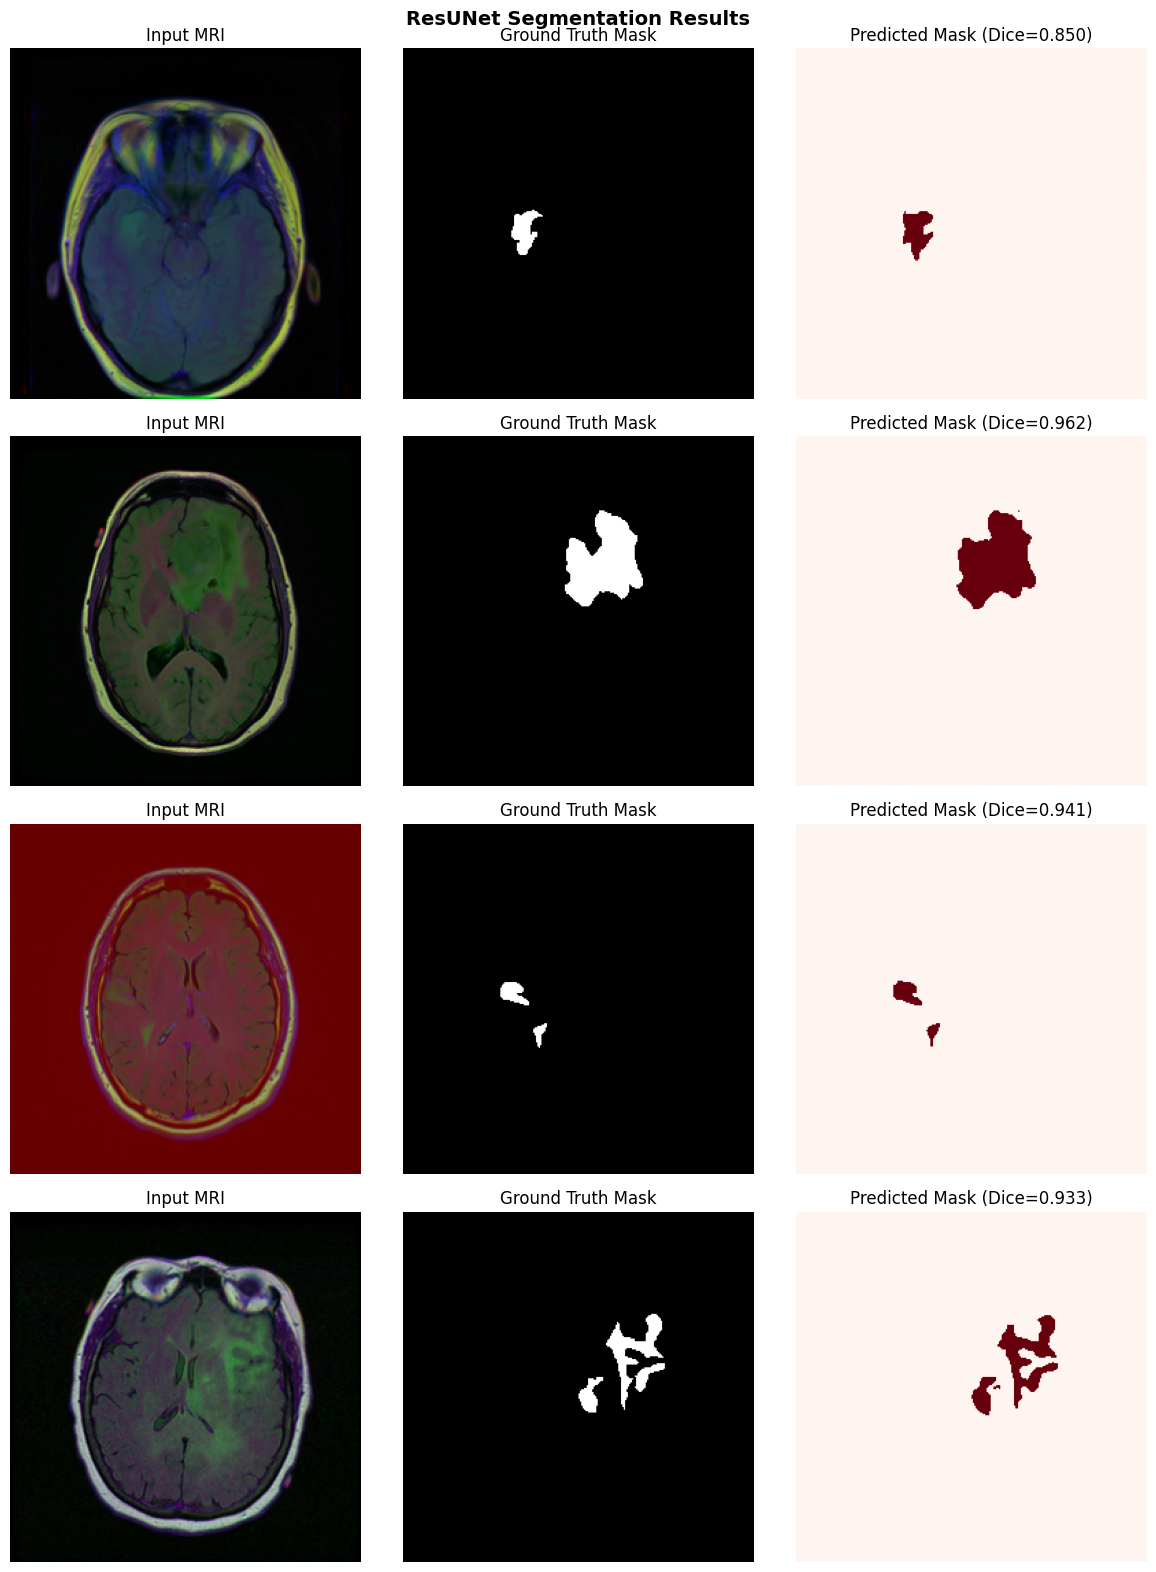

✅ Saved to reports/segmentation_predictions.png


In [76]:
import matplotlib.pyplot as plt
%matplotlib inline

fig, axes = plt.subplots(4, 3, figsize=(12, 16))
sample_gen = SegGen(seg_test, batch_size=16)
sample_imgs, sample_masks = sample_gen[0]
sample_preds = seg_model.predict(sample_imgs, verbose=0)

for i in range(4):
    axes[i][0].imshow(sample_imgs[i])
    axes[i][0].set_title('Input MRI')
    axes[i][0].axis('off')
    axes[i][1].imshow(sample_masks[i,:,:,0], cmap='gray')
    axes[i][1].set_title('Ground Truth Mask')
    axes[i][1].axis('off')
    axes[i][2].imshow(sample_preds[i,:,:,0] > 0.5, cmap='Reds')
    axes[i][2].set_title(f'Predicted Mask (Dice={dice_score(sample_masks[i], sample_preds[i]):.3f})')
    axes[i][2].axis('off')

plt.suptitle('ResUNet Segmentation Results', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('reports/segmentation_predictions.png', dpi=150)
plt.show()
print('✅ Saved to reports/segmentation_predictions.png')

## ✅ Step 12 — Save Everything to Google Drive

In [75]:
import shutil

# Models are already saved to PROJECT_DIR/models/ via ModelCheckpoint
# Save the dataset CSV
df.to_csv(f'{PROJECT_DIR}/data/processed/full_dataset.csv', index=False)

print('✅ All files saved to Google Drive:')
for f in ['models/classifier-resnet-weights.keras',
           'models/ResUNet-weights.keras',
           'reports/segmentation_predictions.png',
           'data/processed/full_dataset.csv',
           'mlflow.db']:
    full = f'{PROJECT_DIR}/{f}'
    exists = os.path.exists(full)
    size = os.path.getsize(full)/1e6 if exists else 0
    print(f'  {"✅" if exists else "❌"} {f} ({size:.1f} MB)')

✅ All files saved to Google Drive:
  ✅ models/classifier-resnet-weights.keras (121.0 MB)
  ✅ models/ResUNet-weights.keras (97.9 MB)
  ✅ reports/segmentation_predictions.png (1.5 MB)
  ✅ data/processed/full_dataset.csv (0.2 MB)
  ✅ mlflow.db (0.8 MB)


In [77]:
import json

metrics = {
    "classifier": {"auc": 0.8443},
    "segmentation": {"avg_dice": 0.9266, "avg_iou": 0.8794}
}
with open(f'{PROJECT_DIR}/reports/final_metrics.json', 'w') as f:
    json.dump(metrics, f, indent=2)
print("✅ Metrics saved")

✅ Metrics saved


#GRAD-CAM FOR XAI

In [84]:
import shutil
src = '/content/drive/MyDrive/mri-brain-tumor-mlops/src/evaluation/gradcam.py'
# Copy the new file from the updated zip, OR just run Cell 2 directly

In [89]:
import sys
sys.path.insert(0, '/content/drive/MyDrive/mri-brain-tumor-mlops')

from src.evaluation.gradcam import run_gradcam

save_path = run_gradcam(
    model=clf_model,       # your trained ResNet50
    test_df=test_df,       # your test DataFrame
    report_dir='/content/drive/MyDrive/mri-brain-tumor-mlops/reports/',
    n_samples=4
)
print(f"✅ Saved to: {save_path}")

/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['input_layer_1']
Received: inputs=Tensor(shape=(1, 256, 256, 3))
  warnings.warn(msg)
/content/drive/MyDrive/mri-brain-tumor-mlops/src/evaluation/gradcam.py:106: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/content/drive/MyDrive/mri-brain-tumor-mlops/src/evaluation/gradcam.py:109: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.savefig(save_path, dpi=150, bbox_inches="tight")


✅ Saved to: /content/drive/MyDrive/mri-brain-tumor-mlops/reports/gradcam_results.png


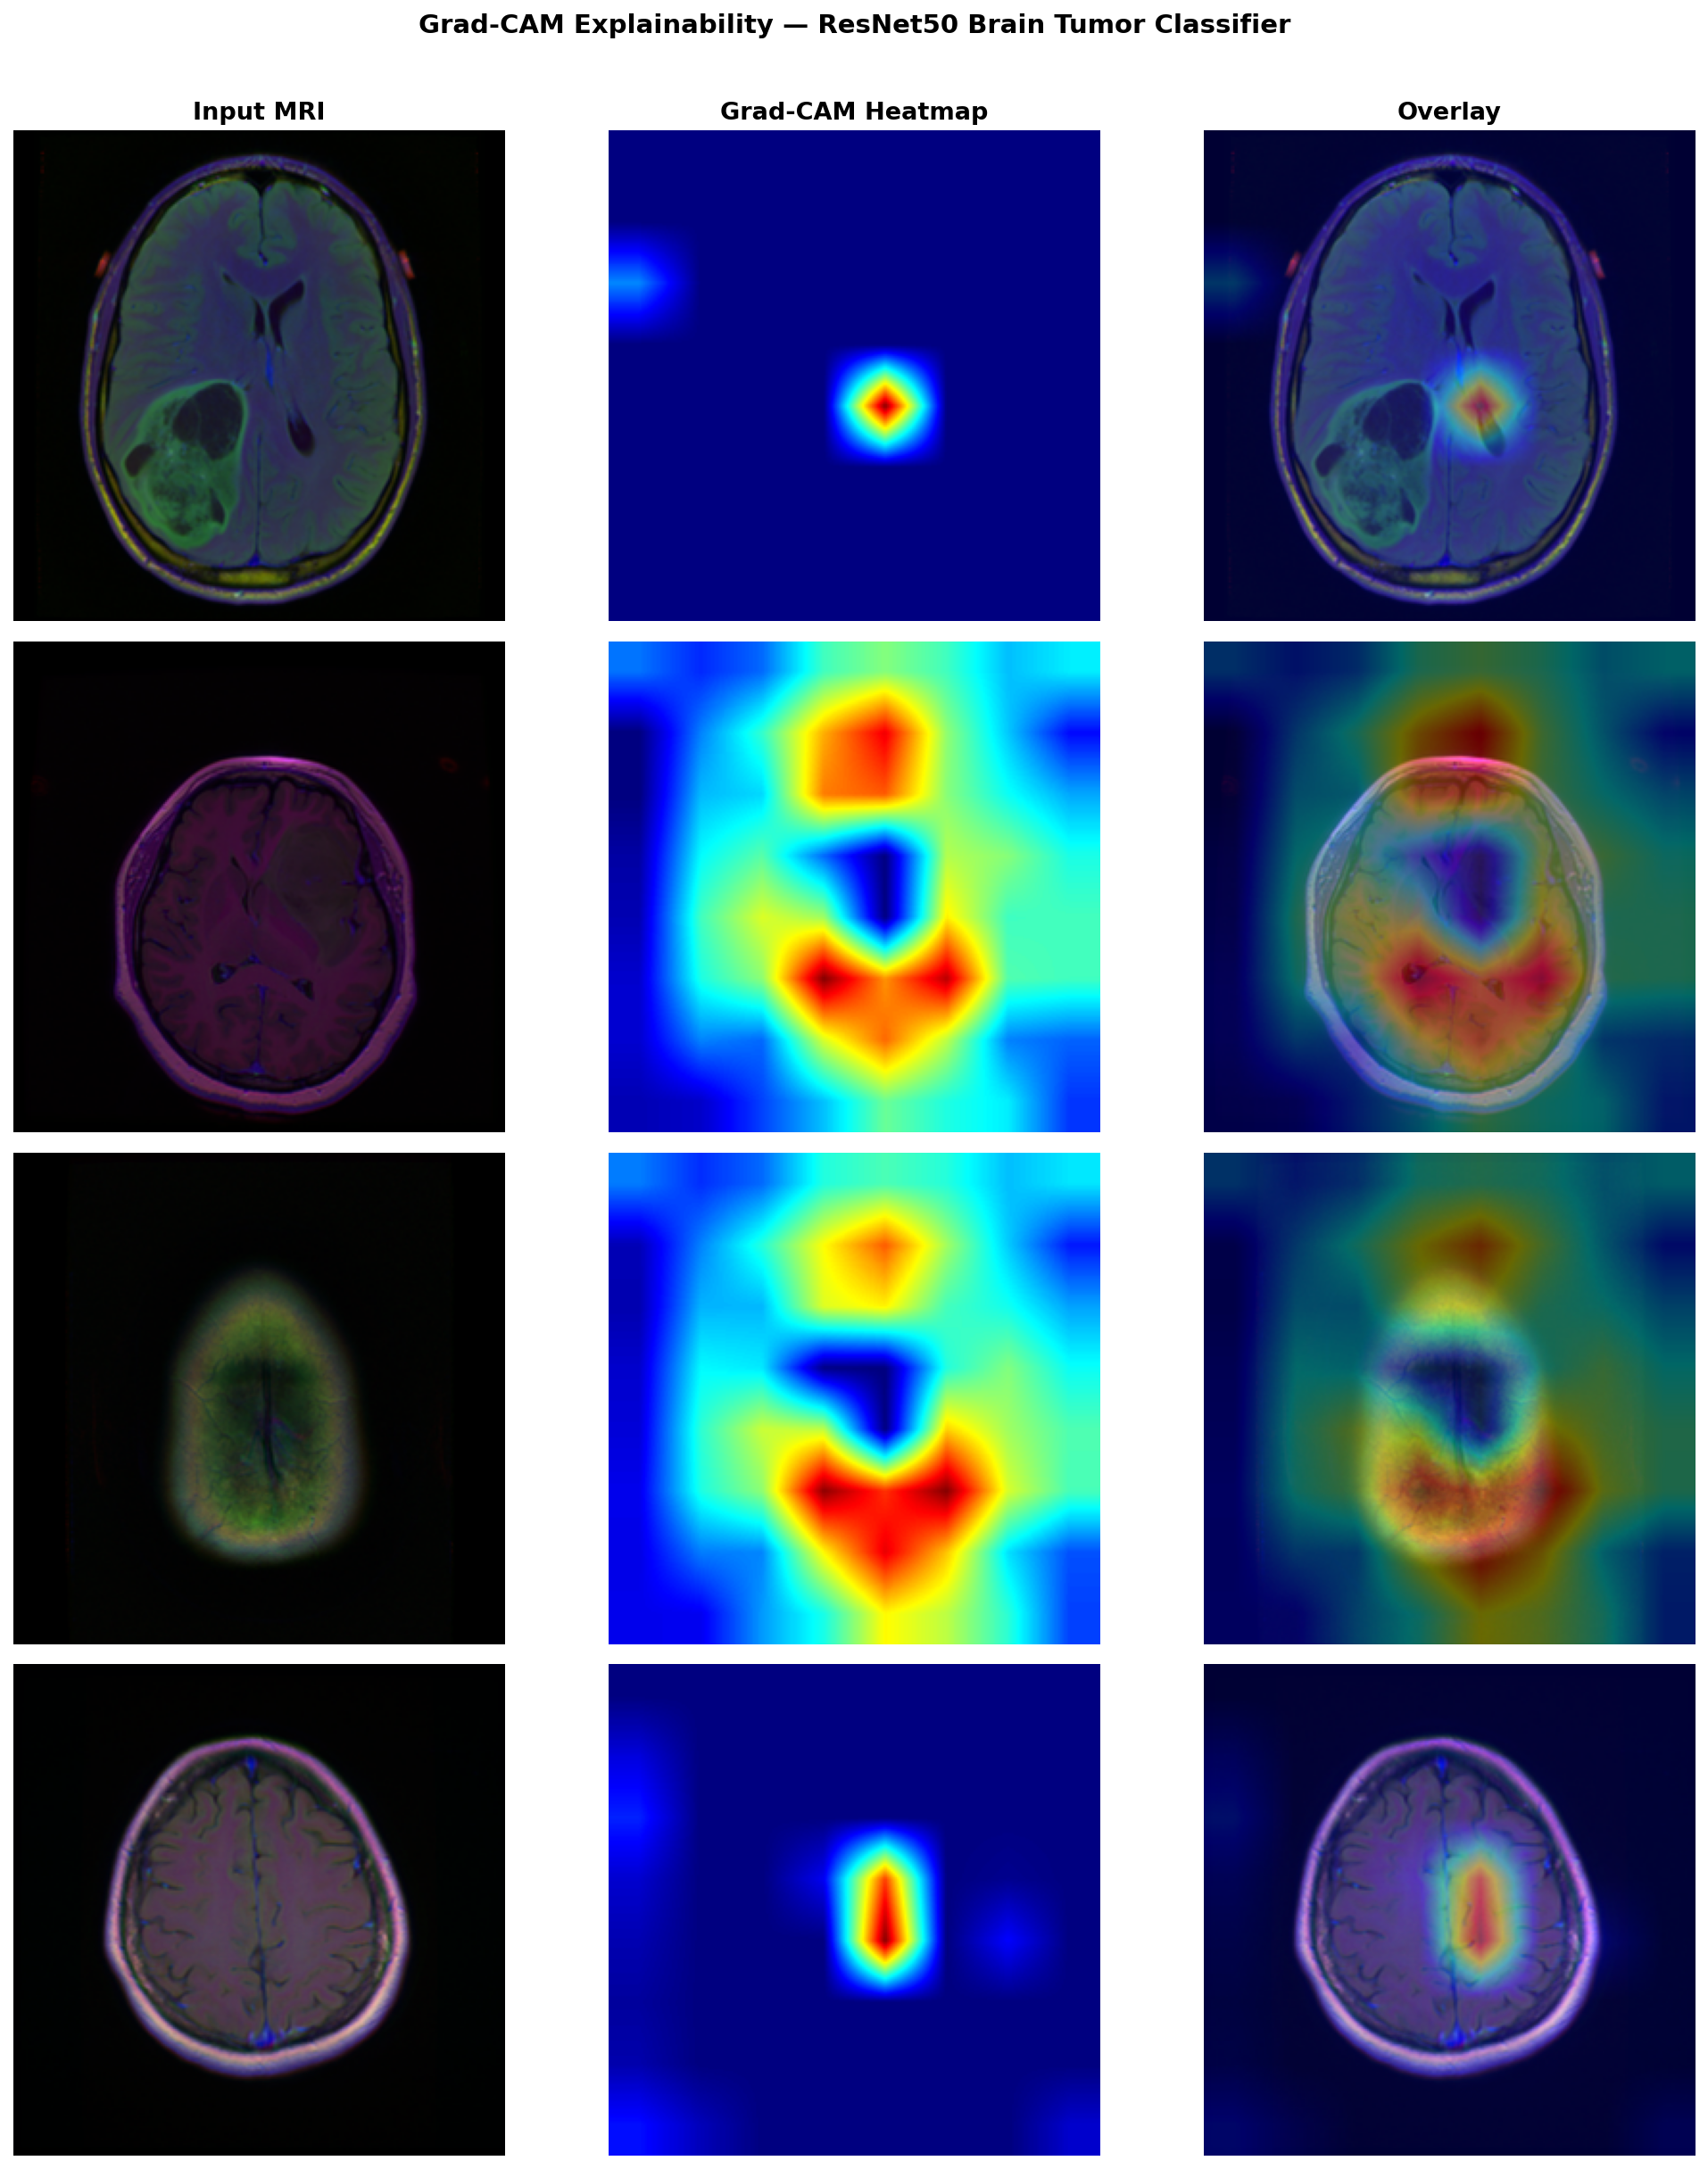

In [90]:
from IPython.display import Image
Image(save_path)